# Score Function V2: Per-Token Variance Features
Test whether per-token CE variance + entropy variance can distinguish
human from BOTH original AI AND humanized AI text.

R(s) fails on humanized because it only captures MEAN perplexity.
Variance captures the PATTERN of perplexity — uniform (AI/humanized) vs varied (human).

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.5.1+cu121', 'torchvision==0.20.1+cu121', '--index-url', 'https://download.pytorch.org/whl/cu121', '-q'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'transformers==4.46.3', 'accelerate==1.1.1', 'bitsandbytes', 'scipy', 'scikit-learn', '-q'])
import torch; print(f'PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0); print(f'GPU: {p.name}, compute {p.major}.{p.minor}')
    x = torch.randn(2,2).cuda(); print(f'OK: {(x@x).sum().item():.2f}'); del x

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 91.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 72.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 44.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 35.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.5.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 98.6 MB/s eta 0:00:00
PyTorch 2.5.1+cu121, CUDA: True
GPU: Tesla P100-PCIE-16GB, compute 6.0
OK: 6.12


In [2]:
import gc, os, sys, json, shutil, warnings
import numpy as np
import torch, torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
BASE = '/kaggle/input'
df = ds = None
for r, dirs, files in os.walk(BASE):
    for f in files:
        if f == 'multimodel_p5e_dataset.json': df = os.path.join(r, f)
        if f == '__init__.py' and 'dna_detectllm' in r: ds = os.path.dirname(os.path.join(r, f))
if not os.path.exists('dna_detectllm') and ds: shutil.copytree(ds, 'dna_detectllm', dirs_exist_ok=True)
sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy
os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'
with open(df) as f: dataset = json.load(f)
print(f'Loaded {len(dataset["human_texts"])} human, {len(dataset["original_ai_texts"])} AI')

Loaded 100 human, 100 AI


In [3]:
# Load models
from transformers import AutoModelForCausalLM, AutoTokenizer
import ctypes
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
gc.collect(); torch.cuda.empty_cache()
tokenizer = AutoTokenizer.from_pretrained('tiiuae/falcon-7b')
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 256; DEVICE = 'cuda:0'
cc = torch.cuda.get_device_properties(0)
if (cc.major, cc.minor) >= (7,0):
    from transformers import BitsAndBytesConfig
    qc = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type='nf4')
    lk = dict(quantization_config=qc, device_map='auto', low_cpu_mem_usage=True); MAX_LEN = 512
else:
    lk = dict(torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
observer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b', **lk); observer.eval()
gc.collect(); torch.cuda.empty_cache()
try: ctypes.CDLL('libc.so.6').malloc_trim(0)
except: pass
performer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b-instruct', **lk); performer.eval()
print(f'Models loaded. MAX_LEN={MAX_LEN}')

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

2026-04-15 13:25:22.952098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776259523.141237      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776259523.192971      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776259523.603397      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776259523.603446      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776259523.603449      23 computation_placer.cc:177] computation placer alr

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Models loaded. MAX_LEN=256


In [4]:
@torch.inference_mode()
def compute_v2(text):
    torch.cuda.empty_cache()
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN, return_token_type_ids=False)
    eg = {k: v.to(DEVICE) for k, v in enc.items()}
    ol = observer(**eg).logits.float()
    pl = performer(**eg).logits.float()
    
    # Standard R(s)
    class E:
        def __init__(s, d): s.input_ids = d['input_ids']; s.attention_mask = d['attention_mask']
        def to(s, dev): s.input_ids = s.input_ids.to(dev); s.attention_mask = s.attention_mask.to(dev); return s
    eo = E(eg)
    ppl = sum_perplexity(eo, pl)
    xppl = entropy(ol, pl, eo, tokenizer.pad_token_id)
    rs = float(ppl[0] / (2 * xppl[0]))
    
    # Per-token features
    shifted = pl[..., :-1, :]
    labels = eg['input_ids'][..., 1:]
    attn = eg['attention_mask'][..., 1:]
    
    # 1. Per-token CE variance
    ce = F.cross_entropy(shifted.transpose(1,2), labels, reduction='none')
    valid_ce = ce[attn.bool()].cpu().numpy()
    ce_var = float(np.var(valid_ce)) if len(valid_ce) > 1 else 0
    ce_mean = float(np.mean(valid_ce)) if len(valid_ce) > 0 else 0
    
    # 2. Performer entropy at each position
    pe = -(F.softmax(pl, dim=-1) * F.log_softmax(pl, dim=-1)).sum(-1)
    valid_pe = pe[..., :-1][attn.bool()].cpu().numpy()
    ent_var = float(np.var(valid_pe)) if len(valid_pe) > 1 else 0
    
    # 3. Confidence ratio variance
    probs = F.softmax(shifted, dim=-1)
    max_p = probs.max(dim=-1).values
    act_p = probs.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
    ratio = (max_p / (act_p + 1e-10))[attn.bool()].cpu().numpy()
    ratio_var = float(np.var(np.log(ratio + 1e-10))) if len(ratio) > 1 else 0
    
    # 4. Observer-performer top-1 agreement rate
    obs_top = ol[..., :-1, :].argmax(dim=-1)
    perf_top = shifted.argmax(dim=-1)
    agree = (obs_top == perf_top).float()[attn.bool()].cpu().numpy()
    agree_rate = float(np.mean(agree)) if len(agree) > 0 else 0
    
    del ol, pl, eg
    return {'rs': rs, 'ce_var': ce_var, 'ce_mean': ce_mean, 'ent_var': ent_var,
            'ratio_var': ratio_var, 'agree_rate': agree_rate}

print(f'Test: {compute_v2("Hello world test")}')

Test: {'rs': 1.1840325593948364, 'ce_var': 5.197925567626953, 'ce_mean': 7.791690826416016, 'ent_var': 1.8097443580627441, 'ratio_var': 5.575863838195801, 'agree_rate': 1.0}


In [5]:
# Score all groups
CKPT = 'v2_checkpoint.json'
if os.path.exists(CKPT):
    all_v2 = json.load(open(CKPT))
    print(f'Loaded checkpoint: {list(all_v2.keys())}')
else:
    all_v2 = {}

groups = {'human': dataset['human_texts'], 'original_ai': dataset['original_ai_texts']}
for mk in ['moonshotai_kimi-k2-instruct', 'gemini-2.0-flash', 'qwen_qwen3-32b']:
    if mk in dataset['humanized']: groups[mk] = dataset['humanized'][mk]

for gname, texts in groups.items():
    if gname in all_v2:
        print(f'{gname}: already done ({len(all_v2[gname])} scores)')
        continue
    print(f'Scoring {gname}...')
    scores = []
    for t in tqdm(texts, desc=gname):
        if t is None: scores.append(None)
        else:
            try: scores.append(compute_v2(t))
            except Exception as e: print(f'Error: {e}'); scores.append(None)
    all_v2[gname] = scores
    with open(CKPT, 'w') as f: json.dump(all_v2, f)
print('All scoring complete!')

Scoring human...


human: 100%|██████████| 100/100 [07:04<00:00,  4.24s/it]


Scoring original_ai...


original_ai: 100%|██████████| 100/100 [07:09<00:00,  4.30s/it]


Scoring moonshotai_kimi-k2-instruct...


...

Scoring gemini-2.0-flash...


gemini-2.0-flash: 100%|██████████| 100/100 [07:07<00:00,  4.28s/it]


Scoring qwen_qwen3-32b...


qwen_qwen3-32b: 100%|██████████| 100/100 [07:11<00:00,  4.31s/it]

All scoring complete!


In [6]:
# Analysis: which features separate human from BOTH AI and humanized?
print('=== FEATURE MEANS ===')
feature_names = ['rs', 'ce_var', 'ce_mean', 'ent_var', 'ratio_var', 'agree_rate']
print(f'{"Feature":<15}', end='')
for g in ['human', 'original_ai', 'moonshotai_kimi-k2-instruct', 'gemini-2.0-flash']:
    label = g.split('_')[0][:8]
    print(f' {label:>10}', end='')
print()
for feat in feature_names:
    print(f'{feat:<15}', end='')
    for g in ['human', 'original_ai', 'moonshotai_kimi-k2-instruct', 'gemini-2.0-flash']:
        vals = [s[feat] for s in all_v2.get(g, []) if s is not None]
        print(f' {np.mean(vals):>10.4f}', end='')
    print()

print('\n=== AUROC BY INDIVIDUAL FEATURE ===')
print(f'{"Feature":<15} {"H vs AI":>8} {"H vs Kimi":>10} {"H vs Gem":>9}')
for feat in feature_names:
    hv = [s[feat] for s in all_v2.get('human', []) if s]
    av = [s[feat] for s in all_v2.get('original_ai', []) if s]
    kv = [s[feat] for s in all_v2.get('moonshotai_kimi-k2-instruct', []) if s]
    gv = [s[feat] for s in all_v2.get('gemini-2.0-flash', []) if s]
    a1 = roc_auc_score([1]*len(hv)+[0]*len(av), hv+av) if av else 0
    a2 = roc_auc_score([1]*len(hv)+[0]*len(kv), hv+kv) if kv else 0
    a3 = roc_auc_score([1]*len(hv)+[0]*len(gv), hv+gv) if gv else 0
    print(f'{feat:<15} {a1:>8.4f} {a2:>10.4f} {a3:>9.4f}')

# LogReg with all features
print('\n=== LOGISTIC REGRESSION: ALL V2 FEATURES ===')
X_h = np.array([[s[f] for f in feature_names] for s in all_v2.get('human',[]) if s])
X_ai = np.array([[s[f] for f in feature_names] for s in all_v2.get('original_ai',[]) if s])
X_k = np.array([[s[f] for f in feature_names] for s in all_v2.get('moonshotai_kimi-k2-instruct',[]) if s])
X_g = np.array([[s[f] for f in feature_names] for s in all_v2.get('gemini-2.0-flash',[]) if s])

if len(X_h) > 0 and len(X_ai) > 0:
    X_train = np.vstack([X_h, X_ai])
    y_train = np.array([1]*len(X_h) + [0]*len(X_ai))
    sc = StandardScaler(); X_ts = sc.fit_transform(X_train)
    clf = LogisticRegression(max_iter=1000); clf.fit(X_ts, y_train)
    
    print(f'Train AUROC (H vs AI): {roc_auc_score(y_train, clf.predict_proba(X_ts)[:,1]):.4f}')
    if len(X_k) > 0:
        X_test = np.vstack([X_h, X_k]); y_test = [1]*len(X_h) + [0]*len(X_k)
        print(f'Test AUROC (H vs Kimi): {roc_auc_score(y_test, clf.predict_proba(sc.transform(X_test))[:,1]):.4f}')
    if len(X_g) > 0:
        X_test = np.vstack([X_h, X_g]); y_test = [1]*len(X_h) + [0]*len(X_g)
        print(f'Test AUROC (H vs Gem):  {roc_auc_score(y_test, clf.predict_proba(sc.transform(X_test))[:,1]):.4f}')
    print(f'Coefficients: {dict(zip(feature_names, clf.coef_[0].round(3)))}')

=== FEATURE MEANS ===
Feature              human   original   moonshot   gemini-2
rs                  0.7017     0.6024     0.7343     0.7061
ce_var              6.2366     5.7730     9.4453     8.5808
ce_mean             2.5522     2.3424     3.4735     3.5632
ent_var             2.5473     2.4613     3.0192     2.6291
ratio_var           4.7366     4.3048     7.4000     6.6735
agree_rate          0.7390     0.7535     0.6980     0.7086

=== AUROC BY INDIVIDUAL FEATURE ===
Feature          H vs AI  H vs Kimi  H vs Gem
rs                0.9916     0.2056    0.4650
ce_var            0.6024     0.0346    0.0763
ce_mean           0.6731     0.0374    0.0221
ent_var           0.5633     0.1924    0.4498
ratio_var         0.6090     0.0426    0.0872
agree_rate        0.4044     0.7710    0.7275

=== LOGISTIC REGRESSION: ALL V2 FEATURES ===
Train AUROC (H vs AI): 0.9976
Test AUROC (H vs Kimi): 0.3159
Test AUROC (H vs Gem):  0.6377
Coefficients: {'rs': np.float64(4.475), 'ce_var': np.float64(

Saved v2_results.json


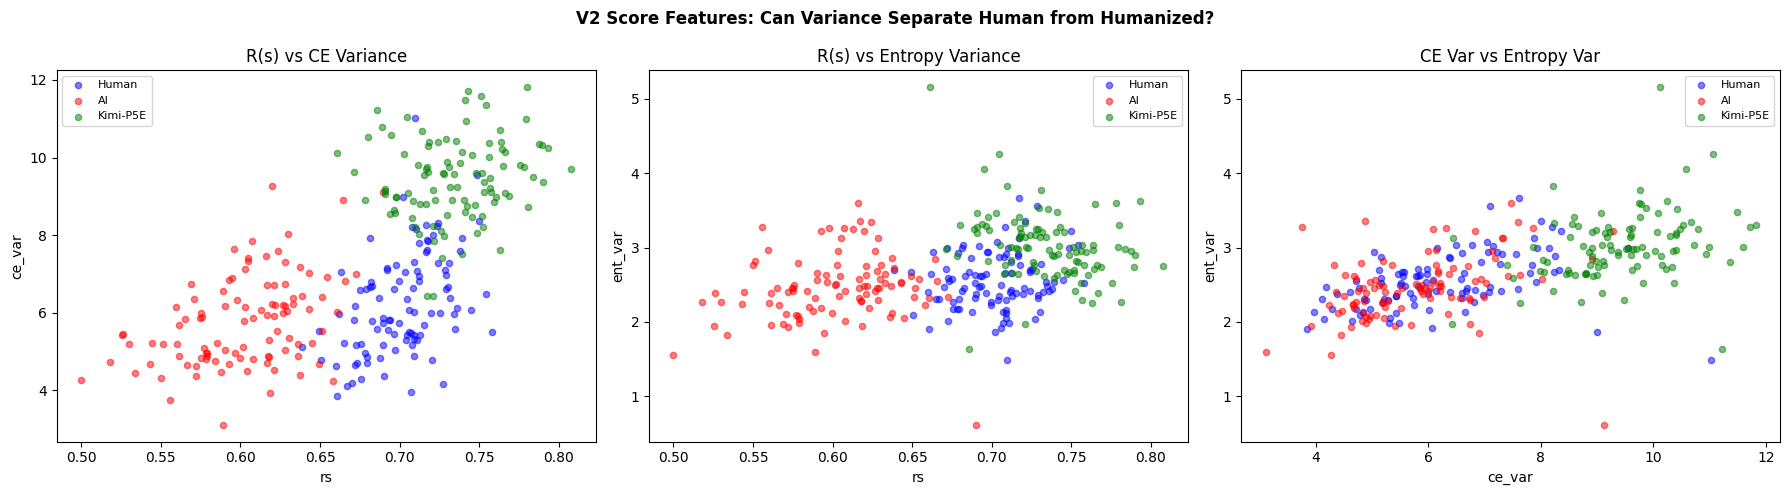

In [7]:
# Save everything
output = {'feature_names': feature_names, 'all_v2': {k: [s for s in v if s] for k, v in all_v2.items()}}
with open('v2_results.json', 'w') as f: json.dump(output, f, indent=2)
print('Saved v2_results.json')

# Plot
if len(X_h) > 0 and len(X_ai) > 0 and len(X_k) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (fx, fy, title) in enumerate([
        ('rs', 'ce_var', 'R(s) vs CE Variance'),
        ('rs', 'ent_var', 'R(s) vs Entropy Variance'),
        ('ce_var', 'ent_var', 'CE Var vs Entropy Var')
    ]):
        ix, iy = feature_names.index(fx), feature_names.index(fy)
        axes[i].scatter(X_h[:,ix], X_h[:,iy], c='blue', alpha=0.5, label='Human', s=20)
        axes[i].scatter(X_ai[:,ix], X_ai[:,iy], c='red', alpha=0.5, label='AI', s=20)
        axes[i].scatter(X_k[:,ix], X_k[:,iy], c='green', alpha=0.5, label='Kimi-P5E', s=20)
        axes[i].set_xlabel(fx); axes[i].set_ylabel(fy); axes[i].set_title(title)
        axes[i].legend(fontsize=8)
    plt.suptitle('V2 Score Features: Can Variance Separate Human from Humanized?', fontweight='bold')
    plt.tight_layout(); plt.savefig('v2_scatter.png', dpi=150); plt.show()